# 📚 AG News Classifier: Streamlit-Powered Text Classification

**Subject:** Natural Language Processing (NLP) – Text Classification  
**Authored by:** Ihsan Ul Haq Afridi  
**Contact:** [LinkedIn Profile](https://www.linkedin.com/in/ihsan-ul-haq-7233a2330/)


# Project Description
This project showcases a machine learning-powered web application for classifying news articles into four categories: World, Sports, Business, and Sci/Tech. Built using Streamlit, the app leverages a pre-trained Support Vector Machine (SVM) model and TF-IDF vectorization to predict the category of user-inputted news headlines or descriptions. The intuitive interface allows users to input text and receive instant predictions, making it an accessible tool for exploring text classification. Perfect for data science enthusiasts, this project demonstrates the integration of scikit-learn, Streamlit, and natural language processing (NLP) for real-world applications. Check out the code on GitHub and try the live demo to classify your own news text! 

In [1]:
import pandas as pd  # Load data manipulation library
import numpy as np  # Support numerical operations
import seaborn as sns  # Visualization library
import matplotlib.pyplot as plt  # Plotting library

from sklearn.model_selection import train_test_split  # Split data into train/test sets
from sklearn.feature_extraction.text import TfidfVectorizer  # Convert text to TF-IDF features

from sklearn.linear_model import LogisticRegression  # Logistic regression classifier
from sklearn.svm import LinearSVC  # Linear Support Vector Classifier
from sklearn.naive_bayes import MultinomialNB  # Naive Bayes classifier
from sklearn.preprocessing import StandardScaler  # Standardize features
from wordcloud import WordCloud  # Generate word cloud visualizations
import re  # Regular expression for text processing


In [2]:
 train_df = pd.read_csv('train.csv')  # Load training dataset from CSV file
test_df = pd.read_csv('test.csv')  # Load test dataset from CSV file

In [3]:
print(train_df.head())  # Display first 5 rows of training dataset
print(test_df.head())  # Display first 5 rows of test dataset

   Class Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   

                                         Description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  
   Class Index                                              Title  \
0            3                  Fears for T N pension after talks   
1            4  The Race is On: Second Private Team Sets Launc...   
2            4      Ky. Company Wins Grant to St

In [4]:
print(train_df.info())  # Display summary of training dataset including column names, data types, and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Class Index  120000 non-null  int64 
 1   Title        120000 non-null  object
 2   Description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB
None


In [5]:
print(test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Class Index  7600 non-null   int64 
 1   Title        7600 non-null   object
 2   Description  7600 non-null   object
dtypes: int64(1), object(2)
memory usage: 178.3+ KB
None


In [6]:
print(train_df.columns)  # Display column names of training dataset
print(test_df.columns)  # Display column names of test dataset

Index(['Class Index', 'Title', 'Description'], dtype='object')
Index(['Class Index', 'Title', 'Description'], dtype='object')


In [7]:
print(train_df.isnull().sum().sort_values(ascending=False))  # Display count of missing values per column in training dataset, sorted in descending order
print(test_df.isnull().sum().sort_values(ascending=False))  # Display count of missing values per column in test dataset, sorted in descending order

Class Index    0
Title          0
Description    0
dtype: int64
Class Index    0
Title          0
Description    0
dtype: int64


In [8]:
print(train_df.shape)
print(test_df.shape)

(120000, 3)
(7600, 3)


In [9]:
pd.set_option('display.max_columns', None)  # Ensures all columns are displayed when printing a DataFrame
pd.set_option('display.expand_frame_repr', True)  # Allows DataFrame to be printed across multiple lines (prevents column wrapping)
pd.set_option('max_colwidth', None)  # Displays full content in each cell without truncating text


In [10]:
 train_df['Text'] = train_df['Title'] + ' ' + train_df['Description']  # Combine Title and Description into a new Text column in training dataset
test_df['Text'] = test_df['Title'] + ' ' + test_df['Description']  # Combine Title and Description into a new Text column in test dataset


In [11]:
print(train_df.head())

   Class Index  \
0            3   
1            3   
2            3   
3            3   
4            3   

                                                                       Title  \
0                          Wall St. Bears Claw Back Into the Black (Reuters)   
1                        Carlyle Looks Toward Commercial Aerospace (Reuters)   
2                            Oil and Economy Cloud Stocks' Outlook (Reuters)   
3               Iraq Halts Oil Exports from Main Southern Pipeline (Reuters)   
4  Oil prices soar to all-time record, posing new menace to US economy (AFP)   

                                                                                                                                                                                                              Description  \
0                                                                                                                          Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cyn

In [12]:
print(train_df['Class Index'].value_counts())  # Display frequency of each unique value in Class Index column of training dataset
print(test_df['Class Index'].value_counts())  # Display frequency of each unique value in Class Index column of test dataset

Class Index
3    30000
4    30000
2    30000
1    30000
Name: count, dtype: int64
Class Index
3    1900
4    1900
2    1900
1    1900
Name: count, dtype: int64


C:\Users\HAIER\AppData\Local\Temp\ipykernel_2000\1199051869.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_labels, y=class_counts, palette='viridis')  # Create bar plot with class labels and counts using viridis color palette


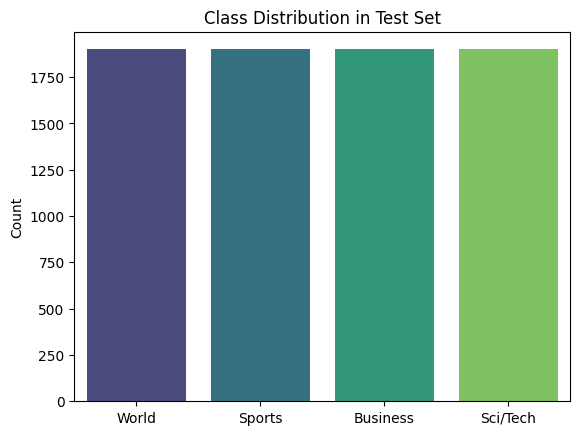

In [13]:
class_counts = test_df['Class Index'].value_counts().sort_index()  # Count occurrences of each class in Class Index, sorted by index
class_labels = ['World', 'Sports', 'Business', 'Sci/Tech']  # Define labels for classes

sns.barplot(x=class_labels, y=class_counts, palette='viridis')  # Create bar plot with class labels and counts using viridis color palette
plt.title('Class Distribution in Test Set')  # Set title for the plot
plt.ylabel('Count')  # Label y-axis as Count
plt.show()  # Display the plot

In [14]:
train_df.head(2)

,Class Index,Title,Description,Text
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.","Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again."
1,3,Carlyle Looks Toward Commercial Aerospace (Reuters),"Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.","Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market."


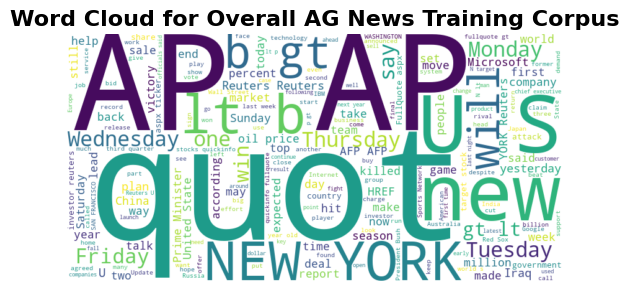

In [15]:
from wordcloud import WordCloud  # Import WordCloud for generating word cloud visualizations

text_corpus = ' '.join(train_df['Text'])  # Concatenate all text in Text column into a single string

wordcloud = WordCloud(width=800, height=400, random_state=42, background_color='white').generate(text_corpus)  # Create word cloud with specified dimensions, random state, and white background

plt.Figure(figsize=(10,5))  # Initialize a new figure with size 10x5 inches

plt.imshow(wordcloud, interpolation='bilinear')  # Display word cloud with bilinear interpolation for smoother rendering

plt.axis('off')  # Hide axes for cleaner visualization
plt.title('Word Cloud for Overall AG News Training Corpus', fontsize=16, fontweight='bold')  # Set title with font size and bold style
plt.show()  # Display the word cloud

In [16]:
from nltk.corpus import stopwords  # Import stopwords from NLTK corpus
stop = stopwords.words('english')  # Load list of English stopwords
len(stop)  # Return the number of stopwords in the list

198

In [17]:
def prepocess_text(text):
    text = text.lower()  # Convert text to lowercase
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # Remove special characters, keeping only alphanumeric and spaces
    text = text.split(" ")  # Split text into list of words
    text = [x for x in text if x not in stop]  # Remove stopwords from the list
    return " ".join(text)  # Join words back into a single string

train_df['processed_Text'] = train_df['Text'].apply(prepocess_text)  # Apply preprocessing to Text column in training dataset
test_df['processed_Text'] = test_df['Text'].apply(prepocess_text)  # Apply preprocessing to Text column in test dataset

In [18]:
print(train_df.head(2))

   Class Index                                                Title  \
0            3    Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reuters)   

                                                                                                                                                                                                              Description  \
0                                                                                                                          Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.   
1  Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.   

                                                                                                                          

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer  # Import TfidfVectorizer for text feature extraction

tf_vectorizer = TfidfVectorizer(ngram_range=(1,2))  # Initialize TF-IDF vectorizer to include unigrams and bigrams

X_train = tf_vectorizer.fit_transform(train_df['processed_Text'])  # Fit and transform training text data to TF-IDF features
X_test = tf_vectorizer.transform(test_df['processed_Text'])  # Transform test text data to TF-IDF features

y_train = train_df['Class Index']  # Extract target labels for training set
y_test = test_df['Class Index']  # Extract target labels for test set

print(f"x_train shape : {X_train.shape}")  # Print shape of training feature matrix
print(f"x_test shape : {X_test.shape}")  # Print shape of test feature matrix
print(f"y_train unique classes : {sorted(y_train.unique())}")  # Print sorted unique class labels in training set
print(f"sample y_train{y_train[:5].tolist()}")  # Print first 5 target labels from training set

x_train shape : (120000, 1570899)
x_test shape : (7600, 1570899)
y_train unique classes : [1, 2, 3, 4]
sample y_train[3, 3, 3, 3, 3]


In [20]:
from sklearn.naive_bayes import MultinomialNB  # Import Multinomial Naive Bayes classifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score, precision_score  # Import evaluation metrics

# Initialize and train the classifier
classifier = MultinomialNB()  # Create Multinomial Naive Bayes classifier instance
classifier.fit(X_train, y_train)  # Train the classifier on training data

# Make predictions
y_pred = classifier.predict(X_test)  # Predict labels for test data

# Evaluate the model
report = classification_report(y_test, y_pred)  # Generate classification report with precision, recall, and F1-score

print(report)  # Print classification report
print("############################################################\n")  # Print separator
conf_matrix = confusion_matrix(y_test, y_pred)  # Compute confusion matrix for predictions
print(conf_matrix)  # Print confusion matrix

              precision    recall  f1-score   support

           1       0.92      0.90      0.91      1900
           2       0.95      0.98      0.97      1900
           3       0.88      0.88      0.88      1900
           4       0.89      0.88      0.89      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600

############################################################

[[1713   60   87   40]
 [  19 1868    7    6]
 [  57   20 1667  156]
 [  71   16  139 1674]]


In [21]:
# Calculate metrics
report = classification_report(y_test, y_pred, output_dict=True)  # Generate classification report as a dictionary for detailed metrics
print(report)  # Print the classification report dictionary
print("\n************************************************")  # Print separator
accuracy = accuracy_score(y_test, y_pred)  # Calculate accuracy of predictions

{'1': {'precision': 0.9209677419354839, 'recall': 0.901578947368421, 'f1-score': 0.9111702127659574, 'support': 1900.0}, '2': {'precision': 0.9511201629327902, 'recall': 0.9831578947368421, 'f1-score': 0.9668737060041408, 'support': 1900.0}, '3': {'precision': 0.8773684210526316, 'recall': 0.8773684210526316, 'f1-score': 0.8773684210526316, 'support': 1900.0}, '4': {'precision': 0.8923240938166311, 'recall': 0.8810526315789474, 'f1-score': 0.8866525423728814, 'support': 1900.0}, 'accuracy': 0.9107894736842105, 'macro avg': {'precision': 0.9104451049343842, 'recall': 0.9107894736842105, 'f1-score': 0.9105162205489028, 'support': 7600.0}, 'weighted avg': {'precision': 0.9104451049343844, 'recall': 0.9107894736842105, 'f1-score': 0.9105162205489028, 'support': 7600.0}}

************************************************


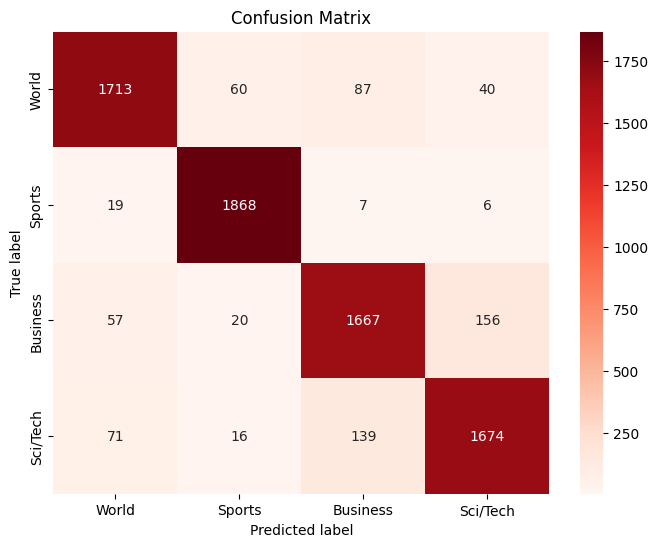

In [22]:
conf_matrix = confusion_matrix(y_test, y_pred)  # Compute confusion matrix for predictions

plt.figure(figsize=(8,6))  # Initialize figure with 8x6 inch size
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', xticklabels=['World', 'Sports', 'Business', 'Sci/Tech'], yticklabels=['World', 'Sports', 'Business', 'Sci/Tech'])  # Create heatmap of confusion matrix with annotations, integer format, Reds colormap, and class labels
plt.xlabel('Predicted label')  # Label x-axis as Predicted label
plt.ylabel('True label')  # Label y-axis as True label
plt.title('Confusion Matrix')  # Set title as Confusion Matrix
plt.show()  # Display the heatmap

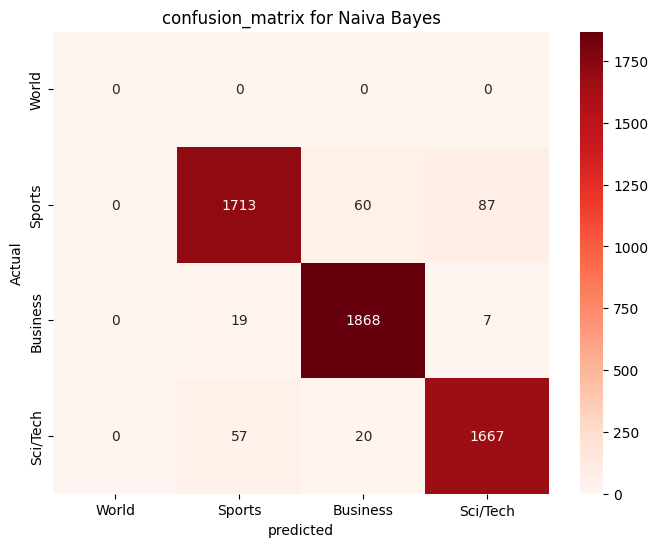


Naiva Bayes classification Report : 
              precision    recall  f1-score   support

           1       0.92      0.90      0.91      1900
           2       0.95      0.98      0.97      1900
           3       0.88      0.88      0.88      1900
           4       0.89      0.88      0.89      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



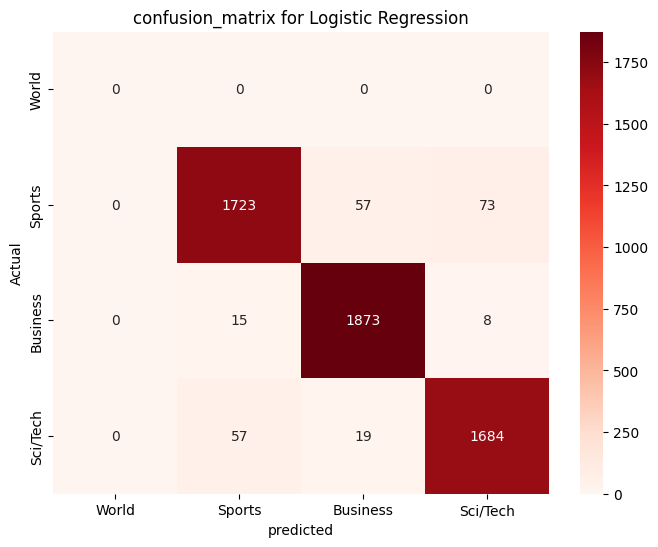


Logistic Regression classification Report : 
              precision    recall  f1-score   support

           1       0.93      0.91      0.92      1900
           2       0.95      0.99      0.97      1900
           3       0.89      0.89      0.89      1900
           4       0.90      0.89      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



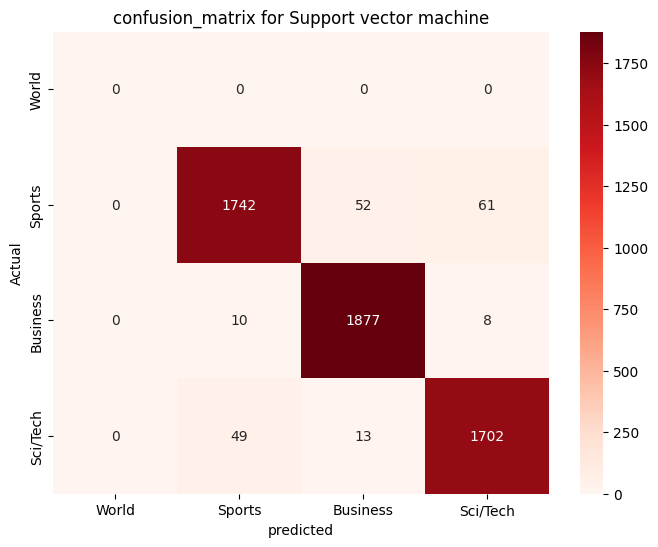


Support vector machine classification Report : 
              precision    recall  f1-score   support

           1       0.94      0.92      0.93      1900
           2       0.96      0.99      0.97      1900
           3       0.91      0.90      0.90      1900
           4       0.90      0.91      0.90      1900

    accuracy                           0.93      7600
   macro avg       0.93      0.93      0.93      7600
weighted avg       0.93      0.93      0.93      7600


 all metrics dictionary : 
{'Naiva Bayes': {'precision': 0.9104451049343842, 'Recall': 0.9107894736842105, 'F1 score': 0.9105162205489028, 'Accuracy': 0.9107894736842105}, 'Logistic Regression': {'precision': 0.9173689680421847, 'Recall': 0.9176315789473684, 'F1 score': 0.9173747814546084, 'Accuracy': 0.9176315789473685}, 'Support vector machine': {'precision': 0.9266455134074068, 'Recall': 0.9268421052631579, 'F1 score': 0.926643203996764, 'Accuracy': 0.9268421052631579}}

 model comparison Table :
          

In [23]:
classifier = {
    'Naiva Bayes': MultinomialNB(),  # Initialize Multinomial Naive Bayes classifier
    'Logistic Regression': LogisticRegression(),  # Initialize Logistic Regression classifier
    'Support vector machine': LinearSVC(),  # Initialize Linear Support Vector Classifier
}

all_metrics = {}  # Dictionary to store evaluation metrics for each classifier

for name, classifier in classifier.items():  # Iterate over each classifier
    classifier.fit(X_train, y_train)  # Train the classifier on training data
    y_pred = classifier.predict(X_test)  # Predict labels for test data

    report = classification_report(y_test, y_pred, output_dict=True)  # Generate classification report as dictionary
    accuracy = accuracy_score(y_test, y_pred)  # Calculate accuracy of predictions

    metrics = {  # Store key metrics (precision, recall, F1-score, accuracy) for macro average
        'precision': report['macro avg']['precision'],
        'Recall': report['macro avg']['recall'],
        'F1 score': report['macro avg']['f1-score'],
        'Accuracy': accuracy
    }

    all_metrics[name] = metrics  # Add metrics to dictionary for current classifier

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3])  # Compute confusion matrix with specified labels

    plt.figure(figsize=(8,6))  # Initialize figure with 8x6 inch size
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_labels, yticklabels=class_labels)  # Create heatmap of confusion matrix
    plt.ylabel('Actual')  # Label y-axis as Actual
    plt.xlabel('predicted')  # Label x-axis as predicted
    plt.title(f'confusion_matrix for {name}')  # Set title with classifier name
    plt.show()  # Display the heatmap

    print(f"\n{name} classification Report : ")  # Print classifier name
    print(classification_report(y_test, y_pred))  # Print detailed classification report

print('\n all metrics dictionary : ')  # Print header for metrics dictionary
print(all_metrics)  # Print metrics dictionary

metrics_df = pd.DataFrame(all_metrics).T.round(3)  # Create DataFrame from metrics, transpose, and round to 3 decimal places
print('\n model comparison Table :')  # Print header for comparison table
print(metrics_df)  # Print model comparison table (corrected to print metrics_df instead of all_metrics)

In [24]:
all_metrics

{'Naiva Bayes': {'precision': 0.9104451049343842,
  'Recall': 0.9107894736842105,
  'F1 score': 0.9105162205489028,
  'Accuracy': 0.9107894736842105},
 'Logistic Regression': {'precision': 0.9173689680421847,
  'Recall': 0.9176315789473684,
  'F1 score': 0.9173747814546084,
  'Accuracy': 0.9176315789473685},
 'Support vector machine': {'precision': 0.9266455134074068,
  'Recall': 0.9268421052631579,
  'F1 score': 0.926643203996764,
  'Accuracy': 0.9268421052631579}}

In [25]:
# Prepare data for grouped bar chart
metrics_df = pd.DataFrame(all_metrics)  # Create DataFrame from all_metrics dictionary
# metrics_df = metrics_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']]  # Commented out: Reorder columns (note: case-sensitive, should match 'precision', 'Recall', 'F1 score')
metrics_df.T  # Transpose DataFrame to have classifiers as rows and metrics as columns

,precision,Recall,F1 score,Accuracy
Naiva Bayes,0.910445,0.910789,0.910516,0.910789
Logistic Regression,0.917369,0.917632,0.917375,0.917632
Support vector machine,0.926646,0.926842,0.926643,0.926842


<Figure size 1000x600 with 0 Axes>

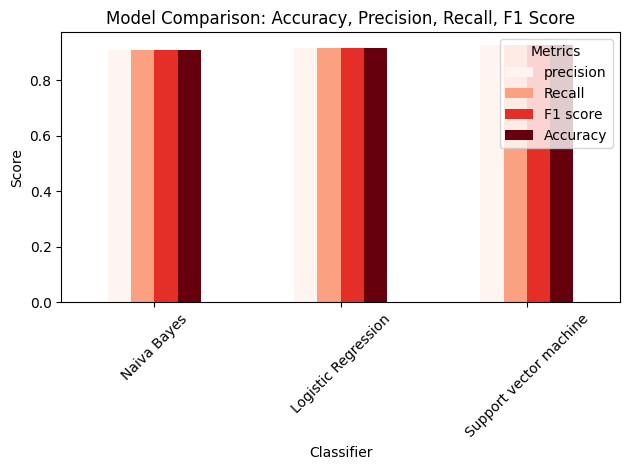

In [26]:
# Plot grouped bar chart for metrics_df
plt.figure(figsize=(10, 6))  # Initialize figure with 10x6 inch size
metrics_df.T.plot(kind='bar', colormap='Reds')  # Create grouped bar chart from transposed metrics_df using Reds colormap
plt.title('Model Comparison: Accuracy, Precision, Recall, F1 Score')  # Set title for the chart
plt.xlabel('Classifier')  # Label x-axis as Classifier
plt.ylabel('Score')  # Label y-axis as Score
plt.legend(title='Metrics')  # Add legend with title Metrics
plt.xticks(rotation=45)  # Rotate x-axis labels by 45 degrees for readability
plt.tight_layout()  # Adjust layout to prevent label cutoff
plt.show()  # Display the bar chart


In [28]:
from sklearn.svm import LinearSVC
import joblib

# Assuming X_train, X_test, y_train, and y_test are already defined from your previous preprocessing
# If not, ensure you have loaded and processed the AG News dataset as done earlier

# Initialize the LinearSVC model
svm_model = LinearSVC()

# Train the model
svm_model.fit(X_train, y_train)

# Save the trained model to a file
joblib.dump(svm_model, 'svm_model.pkl')

# Save the TF-IDF vectorizer
joblib.dump(tf_vectorizer, 'tfidf_vectorizer.pkl')
print("TF-IDF vectorizer saved as tfidf_vectorizer.pkl")
print("SVM model saved as svm_model.pkl")

TF-IDF vectorizer saved as tfidf_vectorizer.pkl
SVM model saved as svm_model.pkl
